# Word Embeddings

## Overview

Sparse bag-of-words vectors (Lab01a) treat every word as independent. This fails to capture the fact that *"dog"* and *"puppy"* are related, or that *"king − man + woman ≈ queen"*.

**Word embeddings** solve this by mapping words to low-dimensional, dense, real-valued vectors where **semantically similar words are geometrically close**. This idea, rooted in the **Distributional Hypothesis** (*"You shall know a word by the company it keeps"* — J.R. Firth, 1957), has revolutionised NLP.

### Key Embedding Models

| Model | Year | Core Idea |
|-------|------|-----------|
| **Word2Vec** (Skip-gram / CBOW) | 2013 | Predict context words from centre (or vice versa); shallow neural net |
| **GloVe** | 2014 | Factorise global word–word co-occurrence statistics |
| **FastText** | 2017 | Word2Vec with sub-word (character n-gram) decomposition; handles OOV words |
| **ELMo** | 2018 | Context-dependent embeddings from a biLSTM language model |
| **BERT / GPT** | 2018+ | Contextualised embeddings from deep Transformers |

This lab covers two stages:
1. **Training Word2Vec from scratch** on a toy corpus using PyTorch — so you understand *exactly* what is being learned.
2. **Using pre-trained Google News Word2Vec** (300-dim, ~3M vocabulary) to explore analogies, similarities, and visualisations.

---

In [ ]:
import numpy as np
import torch

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import matplotlib.pyplot as plt
%matplotlib notebook
%matplotlib inline

from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

def display_scatterplot(model, words):

    if model.shape[1] == 2:
        twodim = model
    else:
        twodim = PCA().fit_transform(model)[:,:2]
    
    plt.style.use('ggplot')
    plt.figure(figsize=(6,6))
    plt.scatter(twodim[:,0], twodim[:,1], edgecolors='k', c='r')
    for word, (x,y) in zip(words, twodim):
        plt.text(x+0.05, y+0.05, word)

# Part 1 — Training Word2Vec from Scratch

## The Skip-gram Model

**Word2Vec** (Mikolov et al., 2013) learns embeddings by training a shallow neural network on a **self-supervised** task:

> *Given a centre word, predict its surrounding context words.*

This is the **Skip-gram** variant. The complementary variant is **CBOW** (Continuous Bag-of-Words): given the context, predict the centre word.

### Architecture

```
centre word (one-hot) → embedding matrix Wi [E × V] → embedding vector → dot product → context word score
```

- **Wi**: Input embedding matrix, shape `[E, V]` (E = embedding dims, V = vocab size)  
- **Wo**: Output embedding matrix, shape `[V, E]`
- The final word embedding is typically the average: `(Wi.T + Wo) / 2`

### Negative Sampling

Instead of a full softmax over the vocabulary (expensive!), **negative sampling** trains a binary classifier:
- **Positive pairs**: actual (centre, context) pairs from the corpus → label 1
- **Negative pairs**: random (centre, noise) pairs → label 0

The objective is to maximise $\log \sigma(\mathbf{w}_o \cdot \mathbf{w}_i)$ for positive pairs and $\log \sigma(-\mathbf{w}_n \cdot \mathbf{w}_i)$ for negative pairs, where $\sigma$ is the sigmoid function.

### Toy Corpus

The corpus below is designed to show structure:
- *she/he* co-occur with *queen/king* and *woman/man* → gender axis
- *london/lisbon* co-occur with *uk/portugal* and *capital* → geography axis

After training, these axes should be visible in the 2D projection of the embeddings.

📖 **Reference**: Mikolov et al., *"Distributed Representations of Words and Phrases and their Compositionality"*, NeurIPS 2013

In [2]:
corpus = [
    'she queen',
    'she woman',
    'he king',
    'he man',
    'london uk capital',
    'lisbon portugal capital',   
]

def tokenize_corpus(corpus):
    tokens = [x.split() for x in corpus]
    return tokens

tokenized_corpus = tokenize_corpus(corpus)
print(tokenized_corpus)

[['she', 'queen'], ['she', 'woman'], ['he', 'king'], ['he', 'man'], ['london', 'uk', 'capital'], ['lisbon', 'portugal', 'capital']]


## Vocabulary

In [3]:
vocabulary = []
for sentence in tokenized_corpus:
    for token in sentence:
        if token not in vocabulary:
            vocabulary.append(token)

word2idx = {w: idx for (idx, w) in enumerate(vocabulary)}
idx2word = {idx: w for (idx, w) in enumerate(vocabulary)}

vocabulary_size = len(vocabulary)
print(word2idx)

{'she': 0, 'queen': 1, 'woman': 2, 'he': 3, 'king': 4, 'man': 5, 'london': 6, 'uk': 7, 'capital': 8, 'lisbon': 9, 'portugal': 10}


## Context Windows and Training Pairs

For each word in the corpus, we look at its **neighbouring words** within a window of size $k$. Each (centre, neighbour) pair is a **positive training example**.

For instance, with `window_size=2` and the sentence *"london uk capital"*:
- Centre *"london"* → context: *"uk"*, *"capital"*
- Centre *"uk"* → context: *"london"*, *"capital"*
- Centre *"capital"* → context: *"london"*, *"uk"*

**Negative sampling** adds random word pairs not seen together as negative examples (label = 0). This teaches the model to push unrelated words apart in the embedding space.

> **Hyperparameter note**: Larger windows capture more topical similarity (e.g., *"bank"* near *"finance"*), while smaller windows capture more syntactic/functional similarity (e.g., *"run"* near *"runs"*).

In [4]:
window_size = 2
idx_pairs = []

# for each sentence
for sentence in tokenized_corpus:
    sentence_indices = [word2idx[word] for word in sentence]
    print(sentence)

    # for each word, treated as center word
    for center_word_pos in range(len(sentence_indices)):

        # for each window position
        for w in range(-window_size, window_size + 1):
            context_word_pos = center_word_pos + w
            # make sure not jump out sentence
            if context_word_pos < 0 or context_word_pos >= len(sentence_indices) or center_word_pos == context_word_pos:
                continue

            context_word_idx = sentence_indices[context_word_pos]

            print("POS:  ",idx2word[sentence_indices[center_word_pos]], " ", idx2word[context_word_idx])
            idx_pairs.append((sentence_indices[center_word_pos], context_word_idx, 1))

## Negative sampling
for word1 in vocabulary:
    for word2 in vocabulary:
        if((word2idx[word1], word2idx[word2], 1) not in idx_pairs):
            print("NEG:  ",word1, " ", word2)
            idx_pairs.append((word2idx[word1], word2idx[word2], 0))

idx_pairs = np.array(idx_pairs)


['she', 'queen']
POS:   she   queen
POS:   queen   she
['she', 'woman']
POS:   she   woman
POS:   woman   she
['he', 'king']
POS:   he   king
POS:   king   he
['he', 'man']
POS:   he   man
POS:   man   he
['london', 'uk', 'capital']
POS:   london   uk
POS:   london   capital
POS:   uk   london
POS:   uk   capital
POS:   capital   london
POS:   capital   uk
['lisbon', 'portugal', 'capital']
POS:   lisbon   portugal
POS:   lisbon   capital
POS:   portugal   lisbon
POS:   portugal   capital
POS:   capital   lisbon
POS:   capital   portugal
NEG:   she   she
NEG:   she   he
NEG:   she   king
NEG:   she   man
NEG:   she   london
NEG:   she   uk
NEG:   she   capital
NEG:   she   lisbon
NEG:   she   portugal
NEG:   queen   queen
NEG:   queen   woman
NEG:   queen   he
NEG:   queen   king
NEG:   queen   man
NEG:   queen   london
NEG:   queen   uk
NEG:   queen   capital
NEG:   queen   lisbon
NEG:   queen   portugal
NEG:   woman   queen
NEG:   woman   woman
NEG:   woman   he
NEG:   woman   king
NE

## Training Loop

The training loop iterates over all (word_i, word_o, label) triplets:
1. Look up the embedding of the centre word in **Wi**
2. Look up the embedding of the context/noise word in **Wo**
3. Compute their dot product and apply sigmoid → probability
4. Compute binary cross-entropy loss against the label
5. Backpropagate and update **Wi** and **Wo**

Notice we do **manual gradient updates** rather than using an optimizer. This is intentional — it shows you exactly which embedding vectors change and by how much.

After training, the final embedding for word $w$ is computed as:

$$\text{embedding}(w) = \frac{\mathbf{w}^\text{in} + \mathbf{w}^\text{out}}{2}$$

The loss should decrease significantly over 100 epochs if the training is working correctly. Watch for the decrease from ~0.95 to ~0.02.

In [5]:
import torch.nn.functional as F

embedding_dims = 4
num_epochs = 100
learning_rate = 0.1

Wi = torch.randn(embedding_dims, vocabulary_size, requires_grad=True).float()
Wo = torch.randn(vocabulary_size, embedding_dims, requires_grad=True).float()

logreg = torch.nn.Sigmoid()
loss = torch.nn.BCELoss()
for epo in range(num_epochs):
    train_loss = 0
    idx_pairs = np.random.permutation(idx_pairs)
    for word_i, word_o, label in idx_pairs:
        
        # Get the current word-pair label
        y_label = torch.from_numpy(np.array(label)).float()
        
        # Compute the condiditional probablity between the two words
        z = torch.dot(Wi[:,word_i], Wo[word_o,:])
        p_wo_wi = logreg(z)

        # Compute the error with the positive/negative label
        output = loss(p_wo_wi, y_label)
        train_loss += output

        # Propagate the error backward and update the parameters
        output.backward()
        Wi[:,word_i].data -= learning_rate * Wi.grad.data[:,word_i]
        Wo[word_o,:].data -= learning_rate * Wo.grad.data[word_o,:]

        # Reset
        Wi.grad.data.zero_()
        Wo.grad.data.zero_()
                
    if epo % 10 == 0:    
        print(f'Loss at epo {epo}: {train_loss/len(idx_pairs)}')

w2v = (Wi.T+Wo)/2

Loss at epo 0: 0.9079563617706299
Loss at epo 10: 0.2670401930809021
Loss at epo 20: 0.1664375364780426
Loss at epo 30: 0.11898426711559296
Loss at epo 40: 0.07757557928562164
Loss at epo 50: 0.0482608824968338
Loss at epo 60: 0.031546950340270996
Loss at epo 70: 0.022562481462955475
Loss at epo 80: 0.01714947074651718
Loss at epo 90: 0.01364149246364832


## Visualize the embeddings

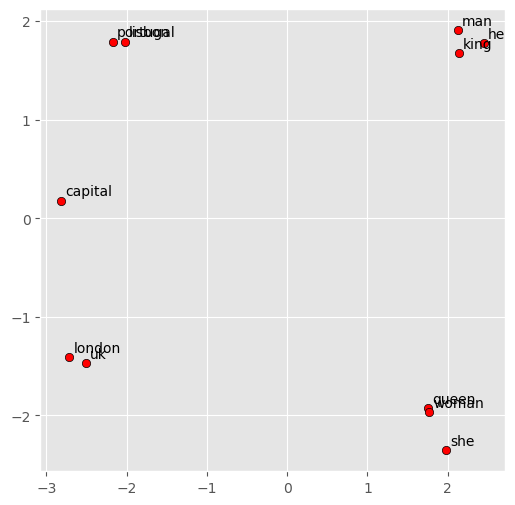

In [6]:
display_scatterplot(w2v.detach().numpy(), vocabulary)


In [7]:
w2v

tensor([[ 0.8289, -0.3180,  0.3163, -2.8430],
        [ 0.5120,  0.0910,  0.2075, -2.4144],
        [ 0.5448,  0.1208,  0.1741, -2.4506],
        [ 0.4313,  1.5975,  2.4168,  0.2956],
        [ 0.3379,  1.4995,  2.1255,  0.3754],
        [ 0.0721,  1.6960,  2.1921,  0.5103],
        [-0.5784, -0.6106, -3.1798,  0.4507],
        [-0.1435, -0.9989, -2.8845,  0.3801],
        [-0.8623, -1.1791, -1.9457,  1.7269],
        [-0.9414, -0.7350, -0.4023,  2.5773],
        [-1.1582, -1.1427, -0.3023,  2.5842]], grad_fn=<DivBackward0>)

# Part 2 — Pre-trained Word Embeddings

## Why Pre-trained Embeddings?

Training Word2Vec from scratch requires a **large corpus** to learn reliable statistics. The toy corpus above has only 6 sentences — real-world training uses billions of words.

Fortunately, researchers have released embeddings pre-trained on massive corpora:

| Model | Corpus | Vocabulary | Dimensions |
|-------|--------|-----------|------------|
| **Word2Vec** (Google News) | 100B words | 3M | 300 |
| **GloVe** (Wikipedia + Gigaword) | 6B tokens | 400K | 50–300 |
| **FastText** (Common Crawl) | 600B tokens | 2M | 300 |

**Gensim** provides a convenient API to load and query these models. The Google News Word2Vec model is loaded below — note it is ~1.6 GB, so it may take a minute to download the first time.

```bash
pip install gensim
```

In [8]:
import gensim.downloader as api
import numpy as np

# Get the interactive Tools for Matplotlib
%matplotlib notebook
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('ggplot')

from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

# Load Word2Vec trained on Google News data
wv = api.load('word2vec-google-news-300')

[==================================================] 100.0% 1662.8/1662.8MB downloaded


## Word Vectors

In [9]:
# Import NumPy
import numpy as np

# Import PCA from scikit-learn
from sklearn.decomposition import PCA

# Import PCA from scikit-learn
import matplotlib.pyplot as plt
%matplotlib notebook
%matplotlib inline

# Import Gensim for the word embeddings
import gensim.downloader as api
from gensim.models import KeyedVectors
from gensim.test.utils import datapath

for i, word in enumerate(wv.key_to_index):
    if i == 10:
        break
    print(word)


</s>
in
for
that
is
on
##
The
with
said


In [10]:
vec_king = wv['king']
print(vec_king)

[ 1.25976562e-01  2.97851562e-02  8.60595703e-03  1.39648438e-01
 -2.56347656e-02 -3.61328125e-02  1.11816406e-01 -1.98242188e-01
  5.12695312e-02  3.63281250e-01 -2.42187500e-01 -3.02734375e-01
 -1.77734375e-01 -2.49023438e-02 -1.67968750e-01 -1.69921875e-01
  3.46679688e-02  5.21850586e-03  4.63867188e-02  1.28906250e-01
  1.36718750e-01  1.12792969e-01  5.95703125e-02  1.36718750e-01
  1.01074219e-01 -1.76757812e-01 -2.51953125e-01  5.98144531e-02
  3.41796875e-01 -3.11279297e-02  1.04492188e-01  6.17675781e-02
  1.24511719e-01  4.00390625e-01 -3.22265625e-01  8.39843750e-02
  3.90625000e-02  5.85937500e-03  7.03125000e-02  1.72851562e-01
  1.38671875e-01 -2.31445312e-01  2.83203125e-01  1.42578125e-01
  3.41796875e-01 -2.39257812e-02 -1.09863281e-01  3.32031250e-02
 -5.46875000e-02  1.53198242e-02 -1.62109375e-01  1.58203125e-01
 -2.59765625e-01  2.01416016e-02 -1.63085938e-01  1.35803223e-03
 -1.44531250e-01 -5.68847656e-02  4.29687500e-02 -2.46582031e-02
  1.85546875e-01  4.47265

## Word Similarity

Word embeddings encode **semantic relatedness** as geometric proximity. Similarity is typically measured with **cosine similarity**:

$$\text{sim}(\mathbf{u}, \mathbf{v}) = \frac{\mathbf{u} \cdot \mathbf{v}}{\|\mathbf{u}\| \|\mathbf{v}\|}$$

A value of 1 means identical direction (very similar), 0 means orthogonal (unrelated), -1 means opposite.

**Expectations for the word pairs below:**
- *car* vs *minivan*: high (both ground vehicles)
- *car* vs *airplane*: medium (both vehicles, different category)
- *car* vs *cereal*: near zero (unrelated domains)
- *car* vs *communism*: near zero (completely unrelated)

The `most_similar()` method finds the top-k nearest neighbours in the embedding space.

In [11]:
pairs = [
    ('car', 'minivan'),   # a minivan is a kind of car
    ('car', 'bicycle'),   # still a wheeled vehicle
    ('car', 'airplane'),  # ok, no wheels, but still a vehicle
    ('car', 'cereal'),    # ... and so on
    ('car', 'communism'),
]
for w1, w2 in pairs:
    print('%r\t%r\t%.2f' % (w1, w2, wv.similarity(w1, w2)))

'car'	'minivan'	0.69
'car'	'bicycle'	0.54
'car'	'airplane'	0.42
'car'	'cereal'	0.14
'car'	'communism'	0.06


In [13]:
print(wv.most_similar(positive=['car', 'batman'], topn=5))

[('Batmobile', 0.5841229557991028), ('vehicle', 0.5716539025306702), ('batmobile', 0.5692458152770996), ('suv', 0.5399793982505798), ('scooter', 0.539139986038208)]


## Word Analogies

One of the most celebrated properties of Word2Vec is that **linear arithmetic on embeddings** captures semantic relationships:

$$\text{king} - \text{man} + \text{woman} \approx \text{queen}$$

This works because the vector offset *man → king* encodes the concept of "royalty". Adding it to *woman* should yield the female equivalent.

More formally, the `analogy(x1, x2, y1)` function answers:

> *"x1 is to x2 as y1 is to ?"*  →  find the word $y2$ such that $\mathbf{y1} + (\mathbf{x2} - \mathbf{x1}) \approx \mathbf{y2}$

### Why does this work?

The geometry emerges because words appearing in similar contexts end up with similar vectors. The offset between two words encodes the **relationship** consistently across many pairs (country→capital, masculine→feminine, verb→past-tense, etc.).

In [14]:
def analogy(x1, x2, y1):
    result = wv.most_similar(positive=[y1, x2], negative=[x1])
    return result[0][0]

In [15]:
analogy('japan', 'japanese', 'brazil')

'brazilian'

In [16]:
analogy('queen', 'king', 'woman')

'man'

In [17]:
analogy('good', 'fantastic', 'bad')

'horrible'

## Visualization

In [18]:
def display_pca_scatterplot(model, words):

    word_vectors = np.array([model[w] for w in words])

    twodim = PCA().fit_transform(word_vectors)[:,:2]
    
    plt.figure(figsize=(6,6))
    plt.scatter(twodim[:,0], twodim[:,1], edgecolors='k', c='r')
    for word, (x,y) in zip(words, twodim):
        plt.text(x+0.05, y+0.05, word)
        
def display_closestwords(model, word):
    
    # get close words
    a = model.similar_by_word(word)
    close_words = [w for (w,s) in a]
    close_words.append(word)
    display_pca_scatterplot(model, close_words)


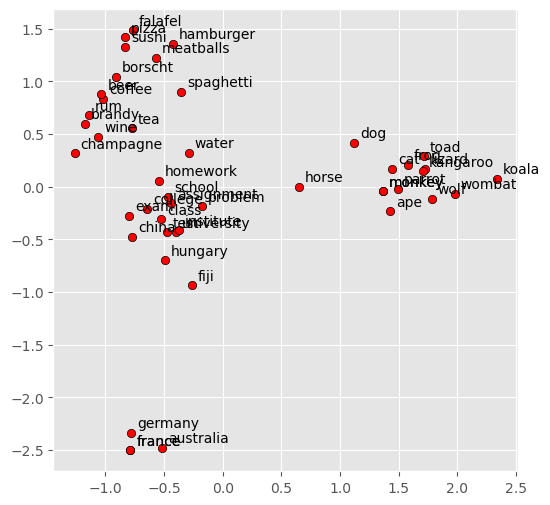

In [19]:
display_pca_scatterplot(wv, 
                        ['coffee', 'tea', 'beer', 'wine', 'brandy', 'rum', 'champagne', 'water',
                         'spaghetti', 'borscht', 'hamburger', 'pizza', 'falafel', 'sushi', 'meatballs',
                         'dog', 'horse', 'cat', 'monkey', 'parrot', 'koala', 'lizard',
                         'frog', 'toad', 'monkey', 'ape', 'kangaroo', 'wombat', 'wolf',
                         'france', 'germany', 'hungary', 'france', 'australia', 'fiji', 'china',
                         'homework', 'assignment', 'problem', 'exam', 'test', 'class',
                         'school', 'college', 'university', 'institute'])

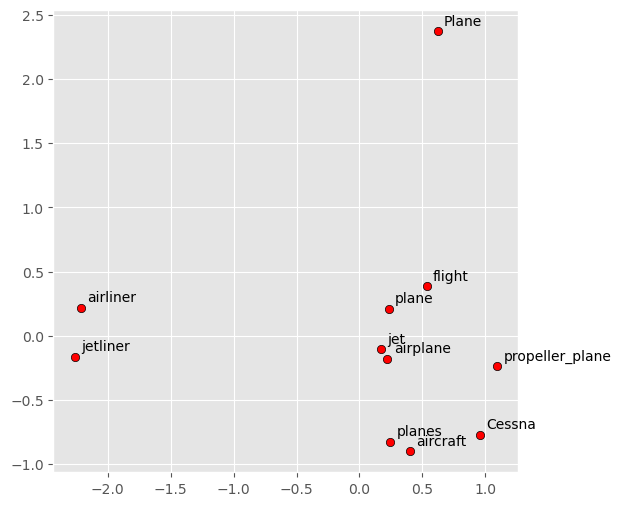

In [20]:
a = display_closestwords(wv, 'plane')


## Exercises

1. **Geometry inspection**: After training the toy Word2Vec, project the embeddings to 2D with PCA. Do *she/queen/woman* cluster together and *he/king/man* cluster separately?

2. **Window size experiment**: Retrain with `window_size=1` and `window_size=3`. How do the embedding clusters change? (Larger windows → more topical similarity.)

3. **Analogy exploration**: Using the pre-trained model, test:
   - `analogy('paris', 'france', 'berlin')` — should return *'germany'*
   - `analogy('slow', 'slowly', 'quick')` — should return *'quickly'*
   - `analogy('walk', 'walked', 'run')` — should return *'ran'*

4. **GloVe vs Word2Vec**: Load a GloVe model (`api.load('glove-wiki-gigaword-100')`) and compare similarity scores and analogy results to Word2Vec. Which do you prefer?

5. **FastText OOV**: FastText handles out-of-vocabulary words via character n-grams. Load `fasttext-wiki-news-subwords-300` and query a misspelled word (e.g., `"photosinthesis"`). Compare to Word2Vec on the same query.

## Further Reading

- [Word2Vec Explained](https://arxiv.org/abs/1402.3722) — Goldberg & Levy (2014)
- [GloVe: Global Vectors for Word Representation](https://nlp.stanford.edu/pubs/glove.pdf) — Pennington et al. (2014)
- [FastText for noisy text](https://fasttext.cc/docs/en/english-vectors.html)
- [Diachronic Word Embeddings](https://nlp.stanford.edu/projects/histwords/) — how word meanings change over time
- [Sentence Embeddings (Doc2Vec)](https://radimrehurek.com/gensim/auto_examples/tutorials/run_doc2vec_lee.html)